***Step 6***

*Import data*

In [115]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

from data import generators, generator_bid_prices, load_profile
from data import Prices_for_loads

# ── Variable names ────────────────────────────────────────────────────
VARIABLES  = list(generators.keys())
conv_names = [v for v in VARIABLES if v.startswith('G')]
wind_names = [v for v in VARIABLES if v.startswith('W')]

# ── Raw data (hour 12) ────────────────────────────────────────────────
gen_costs    = {g: generator_bid_prices[g][12] for g in conv_names}   # marginal costs [$/MWh]
gen_max_caps = {g: generators[g]['Pmax_MW']    for g in conv_names}   # max capacities [MW]
hour_load  = load_profile[12]                                        # total demand [MW]

print(f"Hour 12 load:  {hour12_load:.2f} MW")
print(f"Gen costs:     {gen_costs}")
print(f"Gen maximum capacities:      {gen_max_caps}")

Hour 12 load:  2517.97 MW
Gen costs:     {'G1': 13.32, 'G2': 13.32, 'G3': 20.7, 'G4': 20.93, 'G5': 26.11, 'G6': 10.52, 'G7': 10.52, 'G8': 6.02, 'G9': 5.47, 'G10': 0, 'G11': 10.52, 'G12': 10.89}
Gen maximum capacities:      {'G1': 152, 'G2': 152, 'G3': 350, 'G4': 591, 'G5': 60, 'G6': 155, 'G7': 155, 'G8': 400, 'G9': 400, 'G10': 300, 'G11': 310, 'G12': 350}


**Reserve requirements**

In [116]:
R_up_req   = 0.15 * hour_load   # upward reserve requirement
R_down_req = 0.10 * hour_load   # downward reserve requirement

print(f"Upward reserve requirement:   {R_up_req:.2f} MW  (15% of {hour_load:.2f} MW)")
print(f"Downward reserve requirement: {R_down_req:.2f} MW  (10% of {hour_load:.2f} MW)")

Upward reserve requirement:   377.70 MW  (15% of 2517.97 MW)
Downward reserve requirement: 251.80 MW  (10% of 2517.97 MW)


**European style: reserve market first, then DA**

In [117]:
RESERVE_SUBSET = {'G1', 'G2', 'G3', 'G8', 'G11'}   # same subset as Step 5

reserve_up_offers   = {}   # {generator: (offer_price $/MWh, max_MW)}
reserve_down_offers = {}   # {generator: (offer_price $/MWh, max_MW)}

for g in conv_names:
    if g not in RESERVE_SUBSET:
        continue

    c_i     = gen_costs[g]        # marginal cost of generator g [$/MWh]
    g_max_i = gen_max_caps[g]     # maximum capacity of generator g [MW]

    # Each generator bids its full capacity for both directions
    # Offer price = fraction of marginal cost (opportunity cost of reserving capacity)
    reserve_up_offers[g]   = (0.20 * c_i, g_max_i)   # upward:   20% of marginal cost
    reserve_down_offers[g] = (0.15 * c_i, g_max_i)   # downward: 15% of marginal cost

print("Reserve upward offers (price = 20% of marginal cost, max = full capacity):")
for g, (p, mw) in reserve_up_offers.items():
    print(f"  {g}: {p:.2f} $/MWh   max {mw:.2f} MW  (C_g = {gen_costs[g]:.2f} $/MWh)")

print("\nReserve downward offers (price = 15% of marginal cost, max = full capacity):")
for g, (p, mw) in reserve_down_offers.items():
    print(f"  {g}: {p:.2f} $/MWh   max {mw:.2f} MW  (C_g = {gen_costs[g]:.2f} $/MWh)")

Reserve upward offers (price = 20% of marginal cost, max = full capacity):
  G1: 2.66 $/MWh   max 152.00 MW  (C_g = 13.32 $/MWh)
  G2: 2.66 $/MWh   max 152.00 MW  (C_g = 13.32 $/MWh)
  G3: 4.14 $/MWh   max 350.00 MW  (C_g = 20.70 $/MWh)
  G8: 1.20 $/MWh   max 400.00 MW  (C_g = 6.02 $/MWh)
  G11: 2.10 $/MWh   max 310.00 MW  (C_g = 10.52 $/MWh)

Reserve downward offers (price = 15% of marginal cost, max = full capacity):
  G1: 2.00 $/MWh   max 152.00 MW  (C_g = 13.32 $/MWh)
  G2: 2.00 $/MWh   max 152.00 MW  (C_g = 13.32 $/MWh)
  G3: 3.10 $/MWh   max 350.00 MW  (C_g = 20.70 $/MWh)
  G8: 0.90 $/MWh   max 400.00 MW  (C_g = 6.02 $/MWh)
  G11: 1.58 $/MWh   max 310.00 MW  (C_g = 10.52 $/MWh)


***Solve European Model***

In [118]:
model_R = gp.Model("ReserveMarket_European")
model_R.Params.OutputFlag = 0
model_R.Params.InfUnbdInfo = 1

# Reserve capacity variables
r_up   = {g: model_R.addVar(lb=0, ub=reserve_up_offers[g][1],   name=f'rup_{g}')
          for g in reserve_up_offers}
r_down = {g: model_R.addVar(lb=0, ub=reserve_down_offers[g][1], name=f'rdn_{g}')
          for g in reserve_down_offers}

# Must meet reserve requirements
c_up   = model_R.addConstr(gp.quicksum(r_up[g]   for g in r_up)   >= R_up_req,   name="req_up")
c_down = model_R.addConstr(gp.quicksum(r_down[g] for g in r_down) >= R_down_req, name="req_down")

# (37) Combined up + down reserve cannot exceed generator max capacity
c_combined = {g: model_R.addConstr(
    r_up[g] + r_down[g] <= gen_max_caps[g],
    name=f"combined_{g}")
    for g in r_up}

# Minimise total reserve procurement cost
obj_R = (gp.quicksum(reserve_up_offers[g][0]  * r_up[g]   for g in r_up) +
         gp.quicksum(reserve_down_offers[g][0] * r_down[g] for g in r_down))

model_R.setObjective(obj_R, GRB.MINIMIZE)

model_R.Params.DualReductions = 0
model_R.optimize()

# Reserve clearing prices (duals)
lambda_R_up   = c_up.Pi
lambda_R_down = c_down.Pi

print(f"Reserve up   clearing price: {lambda_R_up:.2f} $/MWh")
print(f"Reserve down clearing price: {lambda_R_down:.2f} $/MWh")
print(f"\nCommitted reserve capacity:")
for g in r_up:
    up_val   = r_up[g].X
    down_val = r_down[g].X if g in r_down else 0.0
    print(f"  {g}: up={up_val:.2f} MW  |  down={down_val:.2f} MW")

# Committed reserve per generator
reserved_up   = {g: r_up[g].X   for g in r_up}
reserved_down = {g: r_down[g].X for g in r_down}


# --- Generator earnings (paid at clearing price) ---
print(f"\nGenerator earnings in reserve market:")
tso_total_payment = 0
for g in RESERVE_SUBSET:
    earn_up   = lambda_R_up   * reserved_up[g]
    earn_down = lambda_R_down * reserved_down[g]
    total_earn = earn_up + earn_down
    tso_total_payment += total_earn
    print(f"  {g}: up={earn_up:.2f} $  |  down={earn_down:.2f} $  |  total={total_earn:.2f} $")

print(f"\nTSO total reserve procurement cost: {tso_total_payment:.2f} $")

Reserve up   clearing price: 1.88 $/MWh
Reserve down clearing price: 1.58 $/MWh

Committed reserve capacity:
  G1: up=0.00 MW  |  down=0.00 MW
  G2: up=0.00 MW  |  down=0.00 MW
  G3: up=0.00 MW  |  down=0.00 MW
  G8: up=377.70 MW  |  down=22.30 MW
  G11: up=0.00 MW  |  down=229.49 MW

Generator earnings in reserve market:
  G1: up=0.00 $  |  down=0.00 $  |  total=0.00 $
  G2: up=0.00 $  |  down=0.00 $  |  total=0.00 $
  G8: up=709.69 $  |  down=35.20 $  |  total=744.89 $
  G11: up=0.00 $  |  down=362.14 $  |  total=362.14 $
  G3: up=0.00 $  |  down=0.00 $  |  total=0.00 $

TSO total reserve procurement cost: 1107.03 $


***Solve DA market (European sequential)***

In [119]:
# --- DA demand = total demand actually. supplied minus reserved fraction (15% up + 10% down = 25%) is not used.
DA_load = hour_load

# Distribute across loads by percentage
Load_DA = [DA_load * (p / 100) for p in Load_percentage]  # MW upper bound per load

# Demand bid prices (same as Step 1)
Demand_price_DA = np.array(sorted(Prices_for_loads[12], reverse=True))  # $/MWh
Load_coefficients_DA = {LOAD_VARIABLES[i]: Demand_price_DA[i] for i in range(len(LOAD_VARIABLES))}

# --- Model ---
model_DA_eu = gp.Model("DA_European_AfterReserve")
model_DA_eu.Params.OutputFlag = 0
model_DA_eu.Params.DualReductions = 0

# Generation variables
p_da = {}
for g in conv_names:
    p_da[g] = model_DA_eu.addVar(lb=0, ub=gen_max_caps[g], name=f'p_{g}')
for wi, w in enumerate(wind_names):
    p_da[w] = model_DA_eu.addVar(lb=0, ub=Wind_DA[wi], name=f'p_{w}')

# Load variables
p_load = {l: model_DA_eu.addVar(lb=0, ub=Load_DA[i], name=f'load_{l}')
          for i, l in enumerate(LOAD_VARIABLES)}

# --- Headroom: p_da[g] <= P_g_max - reserved_up[g] ---
c_headroom = {}
for g in reserved_up:
    c_headroom[g] = model_DA_eu.addConstr(
        p_da[g] <= gen_max_caps[g] - reserved_up[g],
        name=f"headroom_{g}"
    )

# --- Footroom: p_da[g] >= reserved_down[g] ---
c_footroom = {}
for g in reserved_down:
    c_footroom[g] = model_DA_eu.addConstr(
        p_da[g] >= reserved_down[g],
        name=f"footroom_{g}"
    )

# --- Demand balance ---
c_balance = model_DA_eu.addConstr(
    gp.quicksum(p_load[l] for l in p_load) - gp.quicksum(p_da[v] for v in p_da) == 0,
    name="balance"
)

# --- Maximise social welfare ---
obj_DA_eu = (gp.quicksum(Load_coefficients_DA[l] * p_load[l] for l in p_load) -
             gp.quicksum(gen_costs.get(g, 0) * p_da[g] for g in p_da))
model_DA_eu.setObjective(obj_DA_eu, GRB.MAXIMIZE)
model_DA_eu.optimize()

lambda_DA_eu = c_balance.Pi

# --- Results ---
print(f"DA clearing price (after reserve): {lambda_DA_eu:.2f} $/MWh")
print(f"Original DA price (no reserve):    {lambda_DA:.2f} $/MWh")
print(f"Price impact of reserve:           {lambda_DA_eu - lambda_DA:+.2f} $/MWh")

# Producer surplus
print(f"\nProducer surplus per generator:")
total_prod_surplus = 0
for g in p_da:
    if p_da[g].X > 1e-3:
        surplus = (lambda_DA_eu - gen_costs.get(g, 0)) * p_da[g].X
        total_prod_surplus += surplus
        print(f"  {g}: {surplus:.2f} $  (dispatch={p_da[g].X:.2f} MW, cost={gen_costs.get(g,0):.2f} $/MWh)")

# Consumer surplus
print(f"\nConsumer surplus per load:")
total_cons_surplus = 0
for l in p_load:
    if p_load[l].X > 1e-3:
        surplus = (Load_coefficients_DA[l] - lambda_DA_eu) * p_load[l].X
        total_cons_surplus += surplus
        print(f"  {l}: {surplus:.2f} $  (consumption={p_load[l].X:.2f} MW, bid={Load_coefficients_DA[l]:.2f} $/MWh)")

# What each load pays
print(f"\nTotal payment per load:")
for l in p_load:
    if p_load[l].X > 1e-3:
        payment = lambda_DA_eu * p_load[l].X
        print(f"  {l}: {payment:.2f} $")

# Totals
social_welfare_eu = model_DA_eu.ObjVal
print(f"\nTotal producer surplus: {total_prod_surplus:.2f} $")
print(f"Total consumer surplus: {total_cons_surplus:.2f} $")
print(f"Social welfare (DA):    {social_welfare_eu:.2f} $")

DA clearing price (after reserve): 13.32 $/MWh
Original DA price (no reserve):    10.89 $/MWh
Price impact of reserve:           +2.43 $/MWh

Producer surplus per generator:
  G1: 0.00 $  (dispatch=75.92 MW, cost=13.32 $/MWh)
  G6: 434.00 $  (dispatch=155.00 MW, cost=10.52 $/MWh)
  G7: 434.00 $  (dispatch=155.00 MW, cost=10.52 $/MWh)
  G8: 162.82 $  (dispatch=22.30 MW, cost=6.02 $/MWh)
  G9: 3140.00 $  (dispatch=400.00 MW, cost=5.47 $/MWh)
  G10: 3996.00 $  (dispatch=300.00 MW, cost=0.00 $/MWh)
  G11: 868.00 $  (dispatch=310.00 MW, cost=10.52 $/MWh)
  G12: 850.50 $  (dispatch=350.00 MW, cost=10.89 $/MWh)
  W1: 1578.97 $  (dispatch=118.54 MW, cost=0.00 $/MWh)
  W2: 1859.94 $  (dispatch=139.64 MW, cost=0.00 $/MWh)
  W3: 1804.89 $  (dispatch=135.50 MW, cost=0.00 $/MWh)
  W4: 1369.09 $  (dispatch=102.78 MW, cost=0.00 $/MWh)
  W5: 1752.89 $  (dispatch=131.60 MW, cost=0.00 $/MWh)
  W6: 1620.96 $  (dispatch=121.69 MW, cost=0.00 $/MWh)

Consumer surplus per load:
  Load1: 11537.46 $  (consumpt

In [120]:
# Check inputs
print(f"hour_load: {hour_load:.2f} MW")
print(f"DA_load:   {DA_load:.2f} MW")
print(f"Sum Load_DA: {sum(Load_DA):.2f} MW")
print(f"Load_DA: {[round(x,2) for x in Load_DA]}")
print(f"Demand prices (sorted): {[round(x,2) for x in Demand_price_DA]}")

# Check reserve inputs
print(f"\nreserved_up:   {reserved_up}")
print(f"reserved_down: {reserved_down}")

# Check model status
print(f"\nModel status: {model_DA_eu.Status}")  # 2 = optimal

# Check dispatch
print(f"\nDispatch:")
for g in p_da:
    if p_da[g].X > 1e-3:
        print(f"  {g}: {p_da[g].X:.2f} MW")

# Check load served
print(f"\nLoad served:")
for l in p_load:
    print(f"  {l}: {p_load[l].X:.2f} / {Load_DA[LOAD_VARIABLES.index(l)]:.2f} MW")

print(f"\nTotal generation: {sum(p_da[g].X for g in p_da):.2f} MW")
print(f"Total load served: {sum(p_load[l].X for l in p_load):.2f} MW")
print(f"lambda_DA_eu: {lambda_DA_eu:.2f} $/MWh")

hour_load: 2517.97 MW
DA_load:   2517.97 MW
Sum Load_DA: 2517.97 MW
Load_DA: [95.68, 85.61, 158.63, 65.47, 62.95, 120.86, 110.79, 151.08, 153.6, 171.22, 234.17, 171.22, 279.5, 88.13, 294.6, 161.15, 113.31]
Demand prices (sorted): [133.9, 132.21, 129.83, 129.66, 126.21, 125.5, 124.79, 108.85, 103.17, 102.87, 101.68, 93.68, 92.08, 92.01, 88.75, 87.42, 80.96]

reserved_up:   {'G1': 0.0, 'G2': 0.0, 'G3': 0.0, 'G8': 377.69624999999996, 'G11': 0.0}
reserved_down: {'G1': 0.0, 'G2': 0.0, 'G3': 0.0, 'G8': 22.303750000000036, 'G11': 229.49374999999998}

Model status: 2

Dispatch:
  G1: 75.92 MW
  G6: 155.00 MW
  G7: 155.00 MW
  G8: 22.30 MW
  G9: 400.00 MW
  G10: 300.00 MW
  G11: 310.00 MW
  G12: 350.00 MW
  W1: 118.54 MW
  W2: 139.64 MW
  W3: 135.50 MW
  W4: 102.78 MW
  W5: 131.60 MW
  W6: 121.69 MW

Load served:
  Load1: 95.68 / 95.68 MW
  Load2: 85.61 / 85.61 MW
  Load3: 158.63 / 158.63 MW
  Load4: 65.47 / 65.47 MW
  Load5: 62.95 / 62.95 MW
  Load6: 120.86 / 120.86 MW
  Load7: 110.79 / 110.79

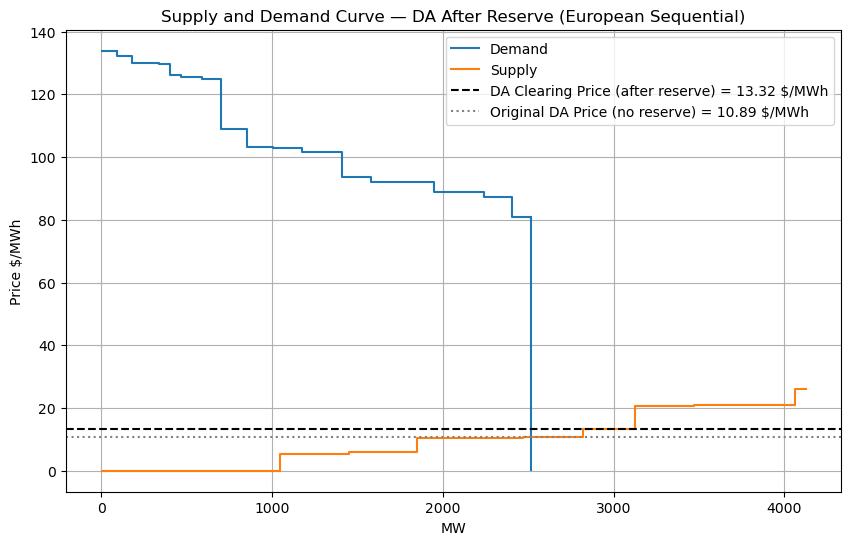

In [121]:
# --- Supply curve ---
supply_data_DA = [
    (gen_costs.get(g, 0), g, p_da[g].X, 
     gen_max_caps[g] if g in conv_names else Wind_DA[wind_names.index(g)])
    for g in p_da
]
supply_data_sorted_DA = sorted(supply_data_DA, key=lambda x: x[0])
sorted_prices_DA      = [x[0] for x in supply_data_sorted_DA]
sorted_caps_DA        = [x[3] for x in supply_data_sorted_DA]
cumulative_supply_DA  = np.cumsum(sorted_caps_DA)

# --- Demand curve ---
demand_sorted_prices = sorted(Load_coefficients_DA.values(), reverse=True)
cumulative_demand_DA = np.cumsum(Load_DA)

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.step(cumulative_demand_DA, demand_sorted_prices, label='Demand', color='tab:blue')
plt.step(cumulative_supply_DA, sorted_prices_DA,     label='Supply', color='tab:orange')

# Aesthetic extensions
plt.hlines(y=0,                       xmin=0,                        xmax=cumulative_supply_DA[0],  color='tab:orange')
plt.hlines(y=demand_sorted_prices[0], xmin=0,                        xmax=Load_DA[0],               color='tab:blue')
plt.vlines(x=cumulative_demand_DA[-1],ymin=0,                        ymax=min(demand_sorted_prices), color='tab:blue')

# Market clearing price
plt.axhline(y=lambda_DA_eu, color='black', linestyle='--',
            label=f'DA Clearing Price (after reserve) = {lambda_DA_eu:.2f} $/MWh')
plt.axhline(y=lambda_DA, color='grey', linestyle=':', 
            label=f'Original DA Price (no reserve) = {lambda_DA:.2f} $/MWh')

plt.xlabel('MW')
plt.ylabel('Price $/MWh')
plt.title('Supply and Demand Curve — DA After Reserve (European Sequential)')
plt.legend()
plt.grid()
plt.show()

***US style: joint reserve + energy market***

In [122]:
# ── STEP 6 US STYLE ───────────────────────────────────────────────────
# Reserve and energy cleared simultaneously in a single optimisation.
# Each generator submits one offer covering both energy and reserve capacity.
# The model decides the split between energy dispatch and reserve commitment.

model_US = gp.Model("Joint_Reserve_Energy_US")
model_US.Params.OutputFlag = 0

p_e  = {}   # energy dispatch
p_ru = {}   # upward reserve
p_rd = {}   # downward reserve

for i, g in enumerate(conv_names):
    g_max_i = gen_cap_dict[i]
    p_e[g]  = model_US.addVar(lb=0, name=f'e_{g}')
    p_ru[g] = model_US.addVar(lb=0, name=f'ru_{g}')
    p_rd[g] = model_US.addVar(lb=0, name=f'rd_{g}')

    # Capacity constraint: energy + upward reserve ≤ Pmax
    model_US.addConstr(p_e[g] + p_ru[g] <= g_max_i, name=f'cap_up_{g}')
    # Downward reserve ≤ energy dispatched (can only reduce what you produce)
    model_US.addConstr(p_rd[g] <= p_e[g],            name=f'cap_dn_{g}')

    # Only reserve subset can offer reserves
    if g not in RESERVE_SUBSET:
        model_US.addConstr(p_ru[g] == 0)
        model_US.addConstr(p_rd[g] == 0)

# Wind — energy only
p_w = {}
for wi, w in enumerate(wind_names):
    p_w[w] = model_US.addVar(lb=0, ub=Wind_DA[wi], name=f'e_{w}')

# Energy balance
model_US.addConstr(
    gp.quicksum(p_e[g] for g in p_e) + gp.quicksum(p_w[w] for w in p_w) == total_demand,
    name="energy_balance"
)

# Reserve requirements
model_US.addConstr(gp.quicksum(p_ru[g] for g in p_ru) >= R_up_req,   name="res_up")
model_US.addConstr(gp.quicksum(p_rd[g] for g in p_rd) >= R_down_req, name="res_down")

# Objective: minimise total cost (energy + reserve opportunity cost)
obj_US = gp.quicksum(gen_costs[g] * (p_e[g] + p_ru[g] + p_rd[g]) for g in p_e)
model_US.setObjective(obj_US, GRB.MINIMIZE)
model_US.optimize()

lambda_energy_US  = model_US.getConstrByName("energy_balance").Pi
lambda_res_up_US  = model_US.getConstrByName("res_up").Pi
lambda_res_dn_US  = model_US.getConstrByName("res_down").Pi

print(f"US-style joint market results:")
print(f"  Energy clearing price:        {lambda_energy_US:.2f} $/MWh")
print(f"  Upward reserve price:         {lambda_res_up_US:.2f} $/MWh")
print(f"  Downward reserve price:       {lambda_res_dn_US:.2f} $/MWh")
print(f"\n  Dispatch:")
for g in p_e:
    if p_e[g].X > 1e-3 or p_ru[g].X > 1e-3 or p_rd[g].X > 1e-3:
        print(f"  {g}: energy={p_e[g].X:.2f} MW  r_up={p_ru[g].X:.2f} MW  r_dn={p_rd[g].X:.2f} MW")
for w in p_w:
    if p_w[w].X > 1e-3:
        print(f"  {w}: energy={p_w[w].X:.2f} MW")

KeyError: 0

***European sequential vs US joint***

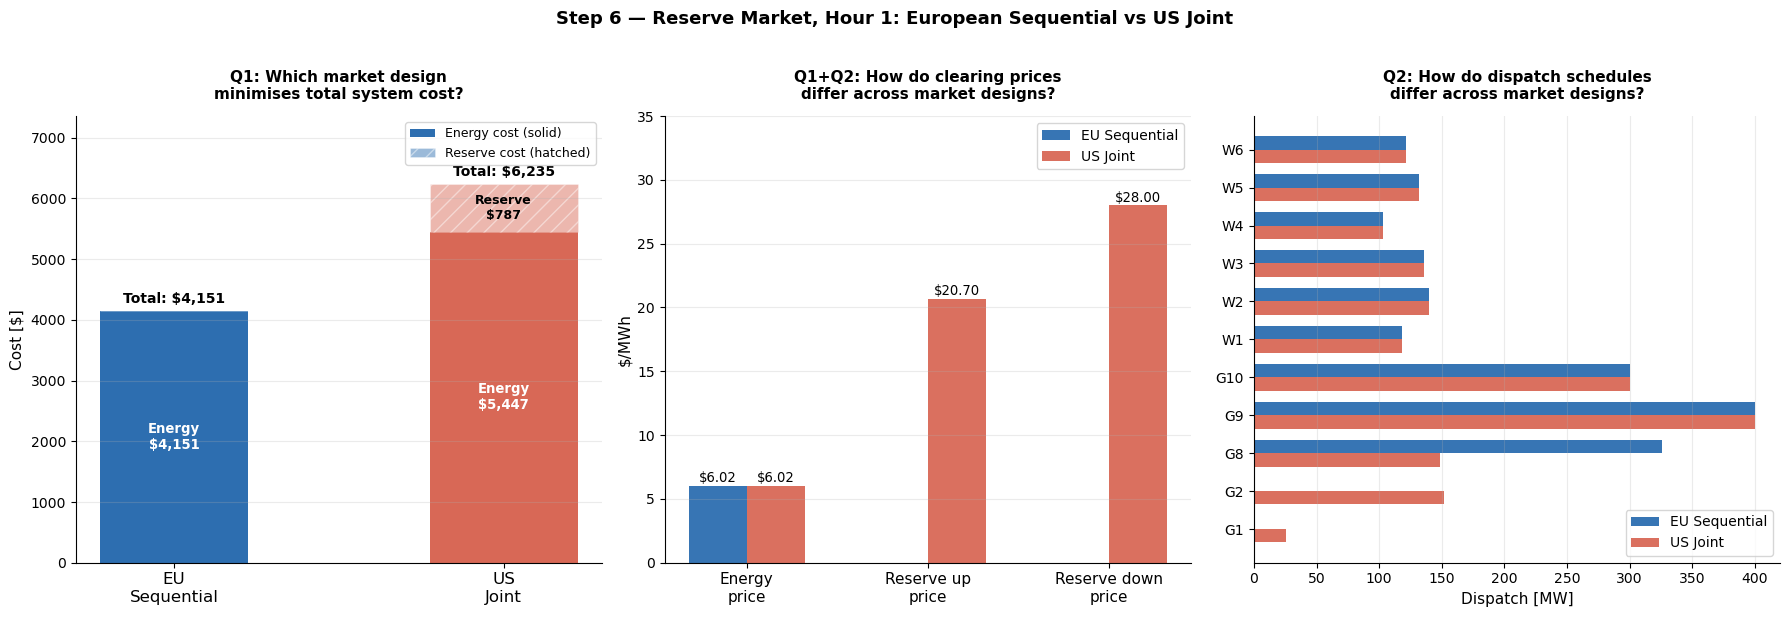

Saved: step6_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── DATA ─────────────────────────────────────────────────────────────
energy_cost_eu = sum(gen_costs.get(g, 0) * p_da[g].X for g in p_da)
energy_cost_us = sum(gen_costs[g] * p_e[g].X for g in p_e)
net_eu = sw_eu - rc_eu
net_us = sw_us - rc_us

models = ['EU\nSequential', 'US\nJoint']
colors_eu = '#2166ac'
colors_us = '#d6604d'

# ── PLOT 1: System cost breakdown (answers: which model is cheaper?) ──
en_costs    = [energy_cost_eu, energy_cost_us]
res_costs   = [rc_eu,          rc_us]
total_costs = [energy_cost_eu + rc_eu, energy_cost_us + rc_us]

ax = axes[0]
bar_w = 0.45
x = np.array([0, 1])

b_e = ax.bar(x, en_costs,  bar_w, color=[colors_eu, colors_us], alpha=0.95)
b_r = ax.bar(x, res_costs, bar_w, bottom=en_costs,
             color=[colors_eu, colors_us], alpha=0.45,
             hatch='//', edgecolor='white', linewidth=0.5)

# Segment labels
for i, (ec, rc, tc) in enumerate(zip(en_costs, res_costs, total_costs)):
    ax.text(i, ec / 2, f'Energy\n${ec:,.0f}',
            ha='center', va='center', fontsize=9.5,
            fontweight='bold', color='white')
    if rc > 30:
        ax.text(i, ec + rc / 2, f'Reserve\n${rc:,.0f}',
                ha='center', va='center', fontsize=9,
                fontweight='bold', color='black')
    ax.text(i, tc + 80, f'Total: ${tc:,.0f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Cost [$]', fontsize=11)
ax.set_ylim(0, max(total_costs) * 1.18)
ax.set_title('Q1: Which market design\nminimises total system cost?',
             fontsize=11, fontweight='bold', pad=12)
ax.legend([b_e, b_r], ['Energy cost (solid)', 'Reserve cost (hatched)'],
          fontsize=9, loc='upper right')
ax.grid(True, alpha=0.25, axis='y')
ax.spines[['top', 'right']].set_visible(False)

# ── PLOT 2: Clearing prices (answers: how do prices differ?) ──────────
ax = axes[1]

price_labels = ['Energy\nprice', 'Reserve up\nprice', 'Reserve down\nprice']
eu_prices    = [lambda_DA_eu,   lambda_R_up,          lambda_R_down]
us_prices    = [lambda_energy_US, lambda_res_up_US,   lambda_res_dn_US]

x3 = np.arange(len(price_labels))
w3 = 0.32
b1 = ax.bar(x3 - w3/2, eu_prices, w3, color=colors_eu, alpha=0.9, label='EU Sequential')
b2 = ax.bar(x3 + w3/2, us_prices, w3, color=colors_us, alpha=0.9, label='US Joint')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        if h > 1e-3:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.04,
                    f'${h:.2f}', ha='center', va='bottom', fontsize=9.5)

ax.set_xticks(x3)
ax.set_xticklabels(price_labels, fontsize=11)
ax.set_ylabel('$/MWh', fontsize=11)
ax.set_ylim(0, max(eu_prices + us_prices) * 1.25)
ax.set_title('Q1+Q2: How do clearing prices\ndiffer across market designs?',
             fontsize=11, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.25, axis='y')
ax.spines[['top', 'right']].set_visible(False)

# ── PLOT 3: Dispatch schedules (answers: who gets scheduled?) ─────────
ax = axes[2]

# Collect all generators with nonzero dispatch in either model
all_gens = sorted(set(
    [g for g in p_da if p_da[g].X > 1e-3] +
    [g for g in p_e  if p_e[g].X  > 1e-3] +
    [w for w in p_w  if p_w[w].X  > 1e-3]
), key=lambda g: (g[0], int(g[1:])))

eu_disp_vals = [p_da[g].X if g in p_da else 0 for g in all_gens]
us_disp_vals = [(p_e[g].X if g in p_e else p_w[g].X if g in p_w else 0) for g in all_gens]

y   = np.arange(len(all_gens))
h   = 0.35
ax.barh(y + h/2, eu_disp_vals, h, color=colors_eu, alpha=0.9, label='EU Sequential')
ax.barh(y - h/2, us_disp_vals, h, color=colors_us, alpha=0.9, label='US Joint')

ax.set_yticks(y)
ax.set_yticklabels(all_gens, fontsize=10)
ax.set_xlabel('Dispatch [MW]', fontsize=11)
ax.set_title('Q2: How do dispatch schedules\ndiffer across market designs?',
             fontsize=11, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.25, axis='x')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Step 6 — Reserve Market, Hour 1: European Sequential vs US Joint',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: step6_comparison.png")